

Date Feature Engineering



In [2]:
from google.colab import files

print("Please upload the 'q3_retail_promotions.csv' file:")
uploaded = files.upload()

Please upload the 'q3_retail_promotions.csv' file:


Saving q3_retail_promotions.csv to q3_retail_promotions.csv


In [3]:
import pandas as pd

# Load dataset
df = pd.read_csv("q3_retail_promotions.csv")

# Convert transaction_date to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

# Extract features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

# Sample preview
df.head()


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Temporal Train-Test Split

In [4]:
# Sort by date
df = df.sort_values("transaction_date")

# Define split index
split_idx = int(len(df) * 0.8)

train = df.iloc[:split_idx]
test = df.iloc[split_idx:]

X_train = train.drop("items_sold", axis=1)
y_train = train["items_sold"]
X_test = test.drop("items_sold", axis=1)
y_test = test["items_sold"]


Preprocessing Pipeline

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Define categorical and numeric features
categorical = ["promotion_type", "location_type", "store_size"]
numeric = ["year", "month", "day_of_week", "is_month_end",
           "is_weekend", "is_festival", "competition_density"]

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
        ("num", StandardScaler(), numeric)
    ]
)


Model Training and Evaluation

Linear Regression - RMSE: 27.125223399614214 MAE: 21.071451412620934
Random Forest - RMSE: 31.18823622422789 MAE: 25.034215277777776


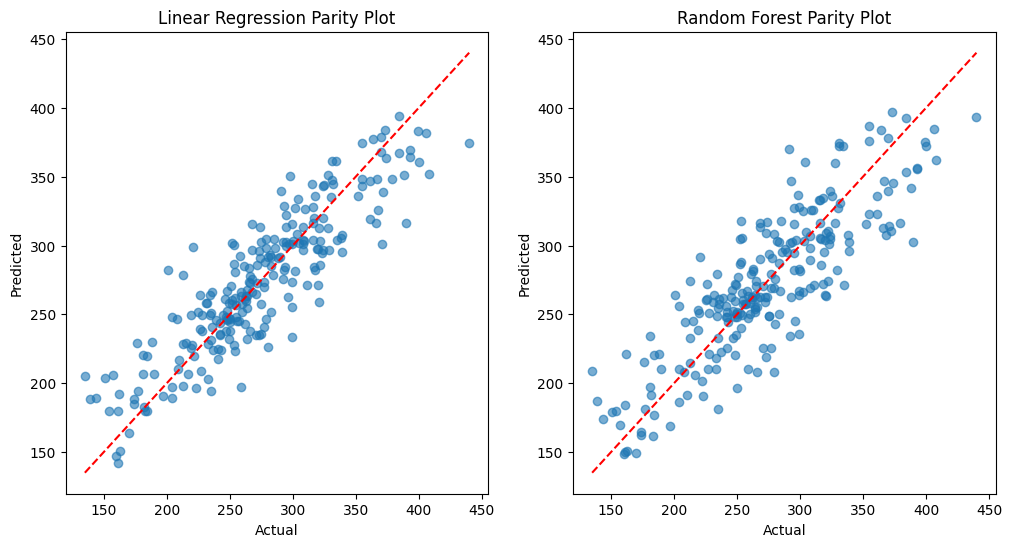

Top 5 influential features:
                      feature  importance
16          num__is_festival    0.173610
10     cat__store_size_small    0.165463
7   cat__location_type_urban    0.107645
13          num__day_of_week    0.085597
15           num__is_weekend    0.069095


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt

# Pipelines
linreg_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

# Fit models
linreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lin = linreg_pipeline.predict(X_test)
y_pred_rf = rf_pipeline.predict(X_test)

# Metrics
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
mae_lin = mean_absolute_error(y_test, y_pred_lin)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Linear Regression - RMSE:", rmse_lin, "MAE:", mae_lin)
print("Random Forest - RMSE:", rmse_rf, "MAE:", mae_rf)

# Parity plots
fig, axes = plt.subplots(1, 2, figsize=(12,6))

axes[0].scatter(y_test, y_pred_lin, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_title("Linear Regression Parity Plot")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

axes[1].scatter(y_test, y_pred_rf, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1].set_title("Random Forest Parity Plot")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.show()

# Feature importances from Random Forest
importances = rf_pipeline.named_steps["model"].feature_importances_
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame({"feature": feature_names, "importance": importances})
top5 = importance_df.sort_values("importance", ascending=False).head(5)
print("Top 5 influential features:\n", top5)
